In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Faccounts.reauth&state=oW4jIhBe41bX3gD7sHgQZtZTaaqG6W&access_type=offline&code_challenge=XcphyB2knjjS3Agx31oNdLCgp4Oy2zrfvqUjHK5RxGc&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning

In [2]:
import os
import hail as hl
import pyspark.sql.functions as f
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_index import StudyIndex
from gentropy.method.window_based_clumping import WindowBasedClumping
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.dataset.study_locus import StudyLocus

hail_dir = os.path.dirname(hl.__file__)
session = Session(hail_home=hail_dir, start_hail=True, extended_spark_conf={"spark.driver.memory": "12g",
    "spark.kryoserializer.buffer.max": "500m","spark.driver.maxResultSize":"3g"})
hl.init(sc=session.spark.sparkContext, log="/dev/null")

Loading BokehJS ...

24/06/12 16:54:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
pip-installed Hail requires additional configuration options in Spark referring
  to the path to the Hail Python module directory HAIL_DIR,
  e.g. /path/to/python/site-packages/hail:
    spark.jars=HAIL_DIR/backend/hail-all-spark.jar
    spark.driver.extraClassPath=HAIL_DIR/backend/hail-all-spark.jar
    spark.executor.extraClassPath=./hail-all-spark.jarRunning on Apache Spark version 3.3.4
SparkUI available at http://mib118093s:4040
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.127-bb535cd096c5
LOGGING: writing to /dev/null


In [3]:
credible_sets=StudyLocus.from_parquet(session,"gs://genetics_etl_python_playground/releases/24.03/credible_set/finngen_susie")
df=credible_sets.df
df.count()
from pyspark.sql.functions import size

# Calculate the size of the locus array for each row
df = df.withColumn('locus_size', size(df['locus']))

#df=df.filter(df["locus_size"]<=100)
df.count()

13966

In [4]:
df=df.toPandas()
df["locus"].iloc[0]

[Row(is95CredibleSet=True, is99CredibleSet=True, logBF=12.6976821115785, posteriorProbability=0.442568649581228, variantId='X_139181000_T_C', pValueMantissa=4.813000202178955, pValueExponent=-8, beta=2.86304, standardError=0.52455, r2Overall=None),
 Row(is95CredibleSet=True, is99CredibleSet=True, logBF=11.8100646453351, posteriorProbability=0.182176887873243, variantId='X_138161852_T_C', pValueMantissa=1.2450000047683716, pValueExponent=-7, beta=2.67436, standardError=0.505853, r2Overall=None),
 Row(is95CredibleSet=True, is99CredibleSet=True, logBF=11.7863227816133, posteriorProbability=0.177902609469606, variantId='X_138777778_T_C', pValueMantissa=1.2769999504089355, pValueExponent=-7, beta=2.66687, standardError=0.504881, r2Overall=None),
 Row(is95CredibleSet=True, is99CredibleSet=True, logBF=11.7803582105345, posteriorProbability=0.176844654969213, variantId='X_138279442_C_T', pValueMantissa=1.284999966621399, pValueExponent=-7, beta=2.66611, standardError=0.504849, r2Overall=None)]

In [5]:
import pandas as pd

# Define a function to process each element in the 'locus' column
def process_locus(locus):
    # Extract the list of 'variantId', split it, and convert the second part to an integer
    positions = [int(row.variantId.split('_')[1]) for row in locus]
    # Return the minimum and maximum positions
    return pd.Series({'min_position': min(positions), 'max_position': max(positions)})

# Apply the function to each element in the 'locus' column and join the result with the original DataFrame
df = df.join(df['locus'].apply(process_locus))

In [6]:
description = (df["max_position"] - df["min_position"]).describe()

# Convert the Series to a DataFrame and transpose it
description = description.to_frame().transpose()

print(description)

     count           mean            std  min       25%      50%        75%         max
0  13966.0  350186.040026  808017.388198  0.0  14477.75  59310.0  231160.75  13055963.0


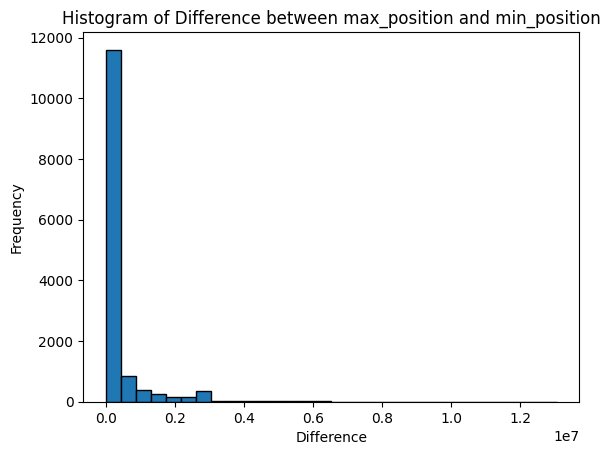

In [7]:
import matplotlib.pyplot as plt

# Calculate the difference between max_position and min_position
difference = df["max_position"] - df["min_position"]

# Plot a histogram of the difference
plt.hist(difference, bins=30, edgecolor='black')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Histogram of Difference between max_position and min_position')
plt.show()

In [8]:
print(sum(difference<=5e5)/len(difference))
print(sum(difference<=1e6)/len(difference))

0.8454818845768295
0.9000429614778749


In [9]:
sum(df["credibleSetIndex"]>1)/len(df)

0.2631390519833882

In [10]:
df_orig=df.copy()

# p<5e-8 and d<=5e5

In [11]:
df = df_orig[df_orig['chromosome'] != 'X']
df=df[df["studyId"]!="FINNGEN_R10_H7_PARASTRA4"]

#df=df[(df["max_position"] - df["min_position"])<=1e6]

pValueExponent_list = df["pValueExponent"].tolist()
pow_list = [pow(10, x) for x in pValueExponent_list]
#df=df[df["pValueMantissa"]*pow_list<=1e-6]
len(df)

13654

In [12]:
sum(df["credibleSetIndex"]>1)/len(df)

0.2660026365900103

In [13]:
unique_studyId = df['studyId'].unique()

## locus breaker

In [14]:
wbc=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/finngen_locus_breaker")
wbc.count()
wbc=wbc.withColumn("locusStart",f.col("locusStart")-150_000).withColumn("locusEnd",f.col("locusEnd")+150_000)
wbc=wbc.toPandas()

wbc_c=wbc[wbc["locusEnd"]-wbc["locusStart"]<=1.5e6]
(wbc_c["locusEnd"]-wbc_c["locusStart"]).describe()

count    1.144300e+04
mean     7.850022e+05
std      2.578216e+05
min      4.841480e+05
25%      5.705110e+05
50%      7.083140e+05
75%      9.444225e+05
max      1.499741e+06
dtype: float64

In [16]:
out=[]
dist=[]
for studyId in unique_studyId:
    df_s=df[df["studyId"]==studyId]
    locus_breaker_s=wbc[wbc["studyId"]==studyId]
    unique_chrom = df_s['chromosome'].unique()
    for chrom in unique_chrom:
        df_c=df_s[df_s["chromosome"]==chrom]
        locus_breaker_c=locus_breaker_s[locus_breaker_s["chromosome"]==chrom]
        for index, row in df_c.iterrows():
                min_position = row['min_position']
                max_position = row['max_position']
                x=(sum((locus_breaker_c["locusStart"]<=min_position) & (locus_breaker_c["locusEnd"]>=max_position)))
                out.append(x)
                if (x==0):
                    dist.append(row["studyLocusId"])
out = [1 if x > 1 else x for x in out]
out_series = pd.Series(out)
value_counts = out_series.value_counts()
print(value_counts)


1    12115
0     1539
Name: count, dtype: int64


## wbc 250kb falnk 500kb

In [17]:
wbc=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/finngen_wbc_250kb_radius")
wbc.count()
wbc=wbc.withColumn("locusStart",f.col("position")-500_000).withColumn("locusEnd",f.col("position")+500_000)
wbc=wbc.toPandas()

(wbc["locusEnd"]-wbc["locusStart"]).describe()

count      27801.0
mean     1000000.0
std            0.0
min      1000000.0
25%      1000000.0
50%      1000000.0
75%      1000000.0
max      1000000.0
dtype: float64

In [18]:
out=[]
dist=[]
for studyId in unique_studyId:
    df_s=df[df["studyId"]==studyId]
    locus_breaker_s=wbc[wbc["studyId"]==studyId]
    unique_chrom = df_s['chromosome'].unique()
    for chrom in unique_chrom:
        df_c=df_s[df_s["chromosome"]==chrom]
        locus_breaker_c=locus_breaker_s[locus_breaker_s["chromosome"]==chrom]
        for index, row in df_c.iterrows():
                min_position = row['min_position']
                max_position = row['max_position']
                x=(sum((locus_breaker_c["locusStart"]<=min_position) & (locus_breaker_c["locusEnd"]>=max_position)))
                out.append(x)
                if (x==0):
                    dist.append(row["studyLocusId"])
out = [1 if x > 1 else x for x in out]
out_series = pd.Series(out)
value_counts = out_series.value_counts()
print(value_counts)


1    11759
0     1895
Name: count, dtype: int64


## wbc 500 kb falnk 750kb

In [19]:
wbc=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/finngen_wbc_500kb_radius")
wbc.count()
wbc=wbc.withColumn("locusStart",f.col("position")-750_000).withColumn("locusEnd",f.col("position")+750_000)
wbc=wbc.toPandas()

(wbc["locusEnd"]-wbc["locusStart"]).describe()

count      19967.0
mean     1500000.0
std            0.0
min      1500000.0
25%      1500000.0
50%      1500000.0
75%      1500000.0
max      1500000.0
dtype: float64

In [20]:
out=[]
dist=[]
for studyId in unique_studyId:
    df_s=df[df["studyId"]==studyId]
    locus_breaker_s=wbc[wbc["studyId"]==studyId]
    unique_chrom = df_s['chromosome'].unique()
    for chrom in unique_chrom:
        df_c=df_s[df_s["chromosome"]==chrom]
        locus_breaker_c=locus_breaker_s[locus_breaker_s["chromosome"]==chrom]
        for index, row in df_c.iterrows():
                min_position = row['min_position']
                max_position = row['max_position']
                x=(sum((locus_breaker_c["locusStart"]<=min_position) & (locus_breaker_c["locusEnd"]>=max_position)))
                out.append(x)
                if (x==0):
                    dist.append(row["studyLocusId"])
out = [1 if x > 1 else x for x in out]
out_series = pd.Series(out)
value_counts = out_series.value_counts()
print(value_counts)


1    12141
0     1513
Name: count, dtype: int64


## wbc 750 kb falnk 1 MB

In [21]:
wbc=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/finngen_wbc_750kb_radius")
wbc.count()
wbc=wbc.withColumn("locusStart",f.col("position")-1_000_000).withColumn("locusEnd",f.col("position")+1_000_000)
wbc=wbc.toPandas()

(wbc["locusEnd"]-wbc["locusStart"]).describe()

count      17141.0
mean     2000000.0
std            0.0
min      2000000.0
25%      2000000.0
50%      2000000.0
75%      2000000.0
max      2000000.0
dtype: float64

In [22]:
out=[]
dist=[]
for studyId in unique_studyId:
    df_s=df[df["studyId"]==studyId]
    locus_breaker_s=wbc[wbc["studyId"]==studyId]
    unique_chrom = df_s['chromosome'].unique()
    for chrom in unique_chrom:
        df_c=df_s[df_s["chromosome"]==chrom]
        locus_breaker_c=locus_breaker_s[locus_breaker_s["chromosome"]==chrom]
        for index, row in df_c.iterrows():
                min_position = row['min_position']
                max_position = row['max_position']
                x=(sum((locus_breaker_c["locusStart"]<=min_position) & (locus_breaker_c["locusEnd"]>=max_position)))
                out.append(x)
                if (x==0):
                    dist.append(row["studyLocusId"])
out = [1 if x > 1 else x for x in out]
out_series = pd.Series(out)
value_counts = out_series.value_counts()
print(value_counts)


1    12431
0     1223
Name: count, dtype: int64


## wbc 1mb falnk 1.5Mb

In [23]:
wbc=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/finngen_wbc_1mb_radius")
wbc.count()
wbc=wbc.withColumn("locusStart",f.col("position")-1_500_000).withColumn("locusEnd",f.col("position")+1_500_000)
wbc=wbc.toPandas()

(wbc["locusEnd"]-wbc["locusStart"]).describe()

count      15592.0
mean     3000000.0
std            0.0
min      3000000.0
25%      3000000.0
50%      3000000.0
75%      3000000.0
max      3000000.0
dtype: float64

In [24]:
out=[]
dist=[]
for studyId in unique_studyId:
    df_s=df[df["studyId"]==studyId]
    locus_breaker_s=wbc[wbc["studyId"]==studyId]
    unique_chrom = df_s['chromosome'].unique()
    for chrom in unique_chrom:
        df_c=df_s[df_s["chromosome"]==chrom]
        locus_breaker_c=locus_breaker_s[locus_breaker_s["chromosome"]==chrom]
        for index, row in df_c.iterrows():
                min_position = row['min_position']
                max_position = row['max_position']
                x=(sum((locus_breaker_c["locusStart"]<=min_position) & (locus_breaker_c["locusEnd"]>=max_position)))
                out.append(x)
                if (x==0):
                    dist.append(row["studyLocusId"])
out = [1 if x > 1 else x for x in out]
out_series = pd.Series(out)
value_counts = out_series.value_counts()
print(value_counts)


1    13391
0      263
Name: count, dtype: int64
